# Análisis exploratorio de datos


In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from utils2 import get_regression_metrics
import pickle

## Paso 1: Definición del problema

> ¿Qué factores diagnósticos son los más influyentes o están más asociados con la predicción de la diabetes en este conjunto de datos?

## Paso 2: Recopilación de datos

> Dataset de [diabetes.csv](https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv)

### Importamos los datos y creamos el DataFrame

In [64]:
df = pd.read_csv("/workspaces/CarlosRestrepo-machine-learning-python/data/raw/diabetis.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Paso 3: Análisis Descriptivo

In [65]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Observaciones:

> ### Observaciones:
> - Existen un total de 768 filas y 9 columnas, entre las cuales encontramos el target o clase a predecir, `Outcome`.
> - Ninguna variable contiene valores nulos.
> - Todas las características son numéricas.

## Paso 4: Limpieza de Datos

### Limpieza de datos: Eliminar duplicados

In [68]:
df.duplicated().sum()

np.int64(0)

### Limpieza de datos: Eliminar información irrelevante

> ### Conclusión:
>
> Todas las características son imprescindibles para realizar una predicción.

## Paso 5: Análisis de Variables

### Análisis de Variables Univariante

#### Análisis de Variables Univariante Numéricas

In [69]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

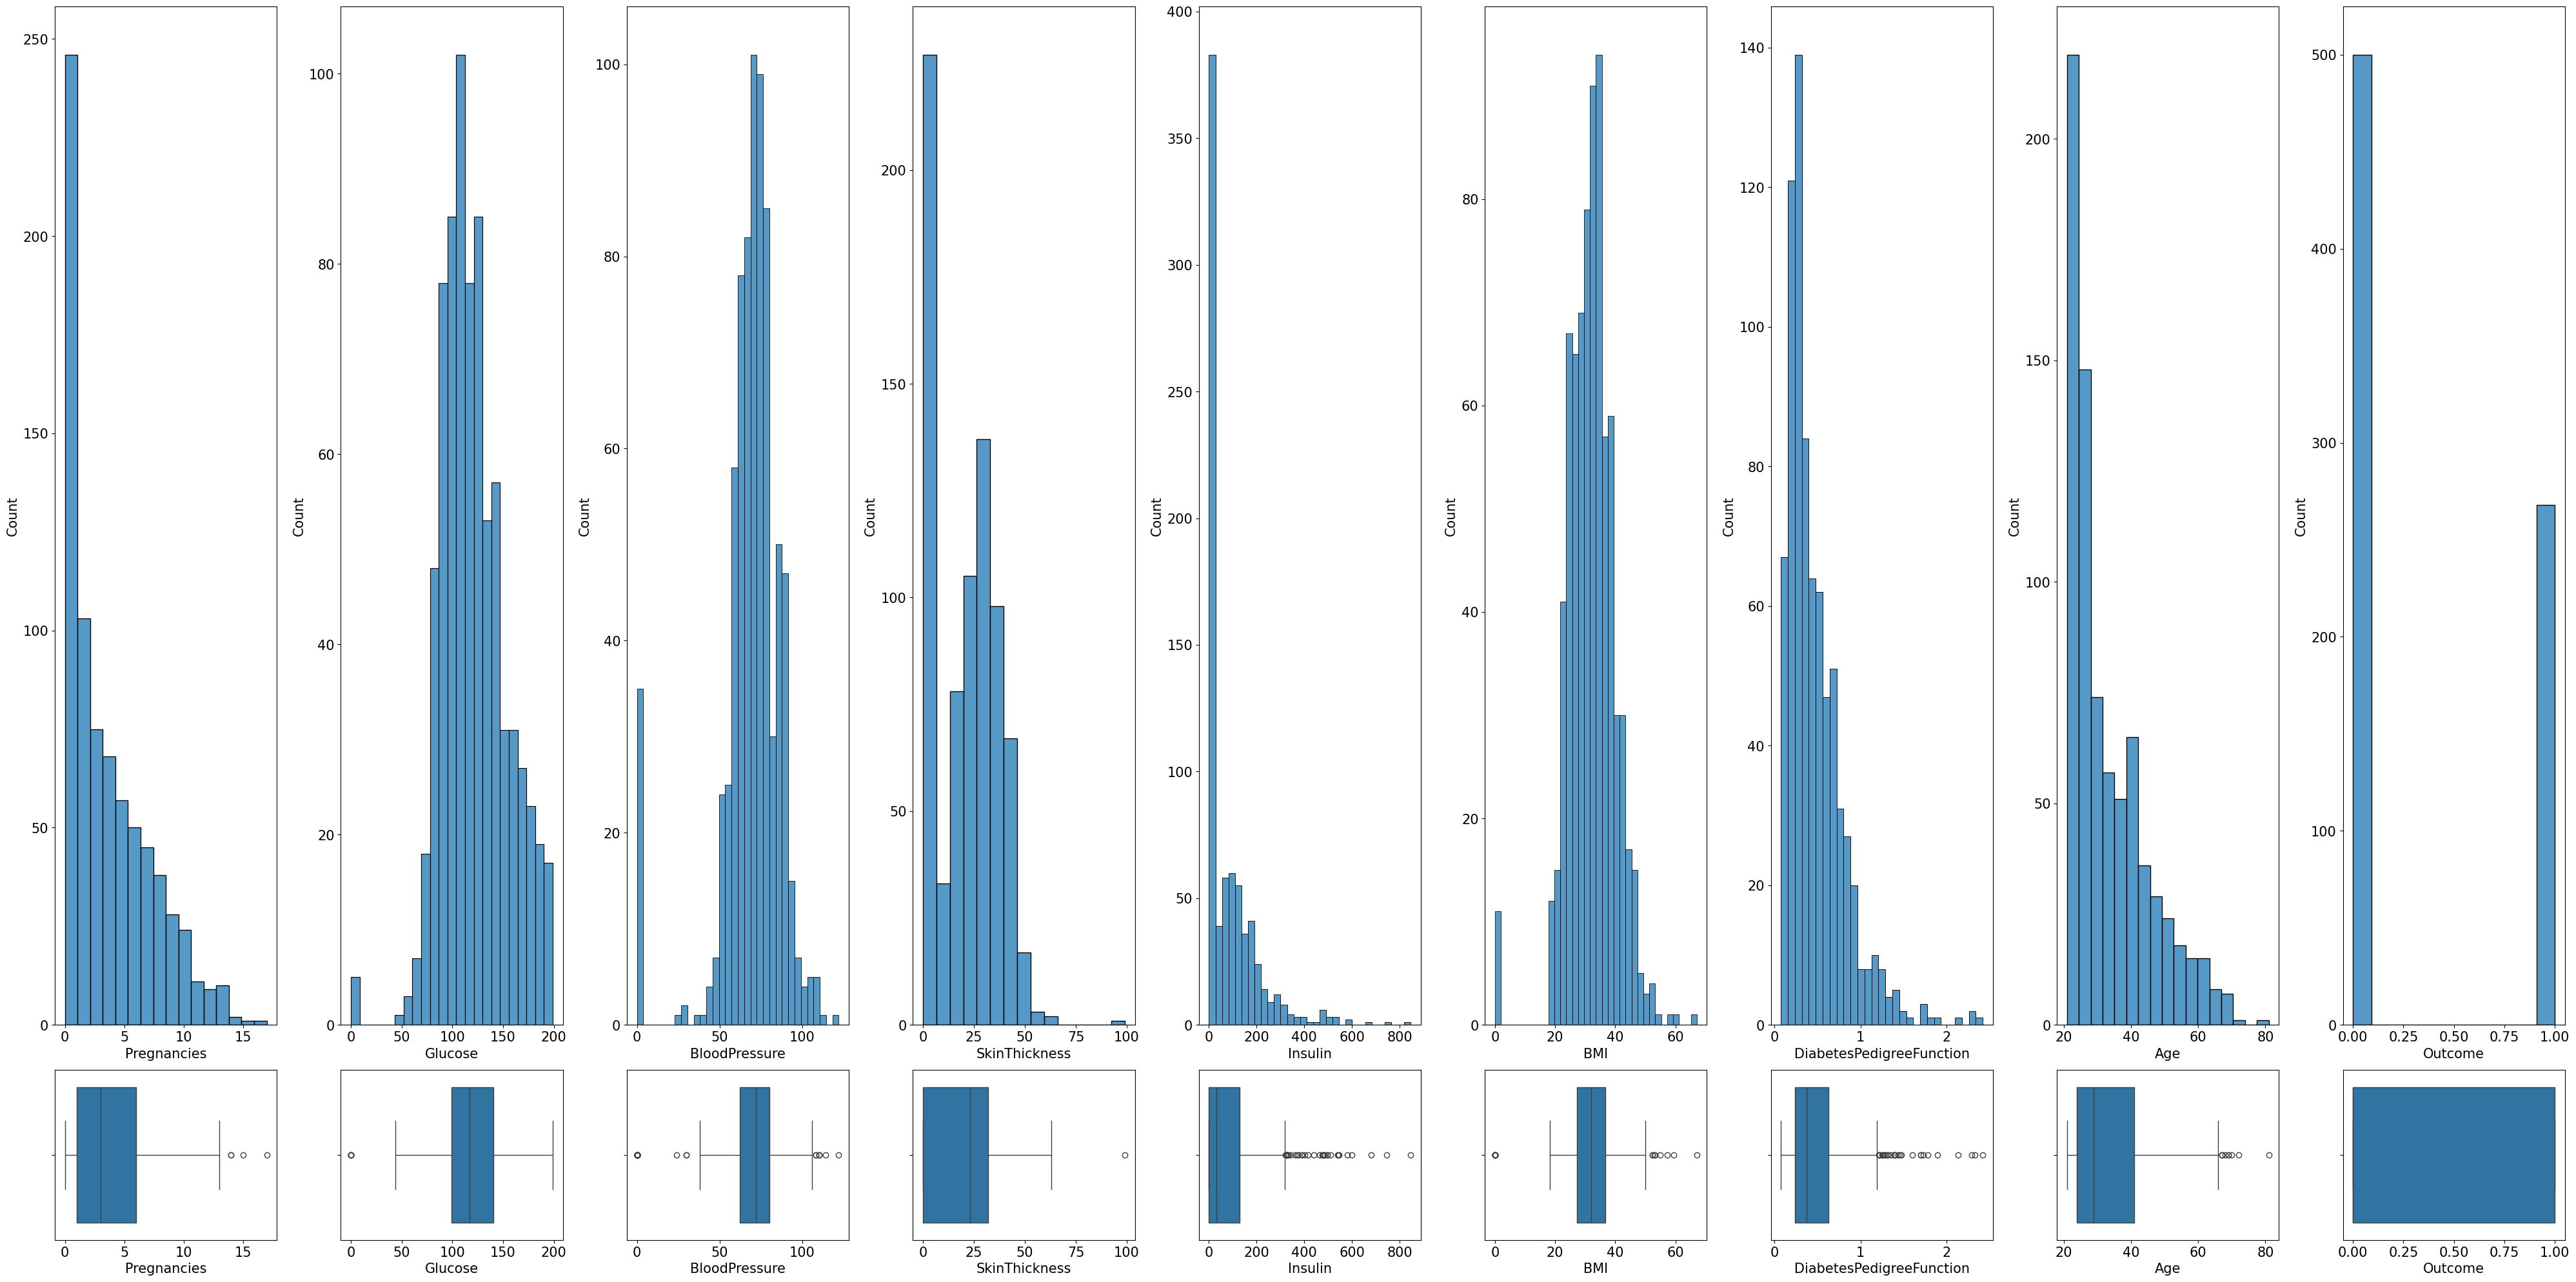

In [70]:
fig, axis = plt.subplots(2, 9, figsize=(40, 20), gridspec_kw={'height_ratios': [6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.labelsize'] = 15

sns.histplot(ax=axis[0, 0], data=df, x='Pregnancies')
sns.boxplot(ax=axis[1, 0], data=df, x='Pregnancies')

sns.histplot(ax=axis[0, 1], data=df, x='Glucose')
sns.boxplot(ax=axis[1, 1], data=df, x='Glucose')

sns.histplot(ax=axis[0, 2], data=df, x='BloodPressure')
sns.boxplot(ax=axis[1, 2], data=df, x='BloodPressure')

sns.histplot(ax=axis[0, 3], data=df, x='SkinThickness')
sns.boxplot(ax=axis[1, 3], data=df, x='SkinThickness')

sns.histplot(ax=axis[0, 4], data=df, x='Insulin')
sns.boxplot(ax=axis[1, 4], data=df, x='Insulin')

sns.histplot(ax=axis[0, 5], data=df, x='BMI')
sns.boxplot(ax=axis[1, 5], data=df, x='BMI')

sns.histplot(ax=axis[0, 6], data=df, x='DiabetesPedigreeFunction')
sns.boxplot(ax=axis[1, 6], data=df, x='DiabetesPedigreeFunction')

sns.histplot(ax=axis[0, 7], data=df, x='Age')
sns.boxplot(ax=axis[1, 7], data=df, x='Age')

sns.histplot(ax=axis[0, 8], data=df, x='Outcome')
sns.boxplot(ax=axis[1, 8], data=df, x='Outcome')


plt.tight_layout()


> #### Observaciones:
> - Se puede observar como hay valores 0 (valores atípicos) en multiples columnas, como: `Preganancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `Age`.
> - Las columnas que contienen mas outliers són `Insuline`, `BMI`, `DiabetesPedigreeFunction` y `Age`.

### Análisis de Variables Multivariante

#### Análisis numérico-numérico

In [71]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

##### Outcome - ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin' ,'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome')
Primero analizamos el target frente a las características numéricas:

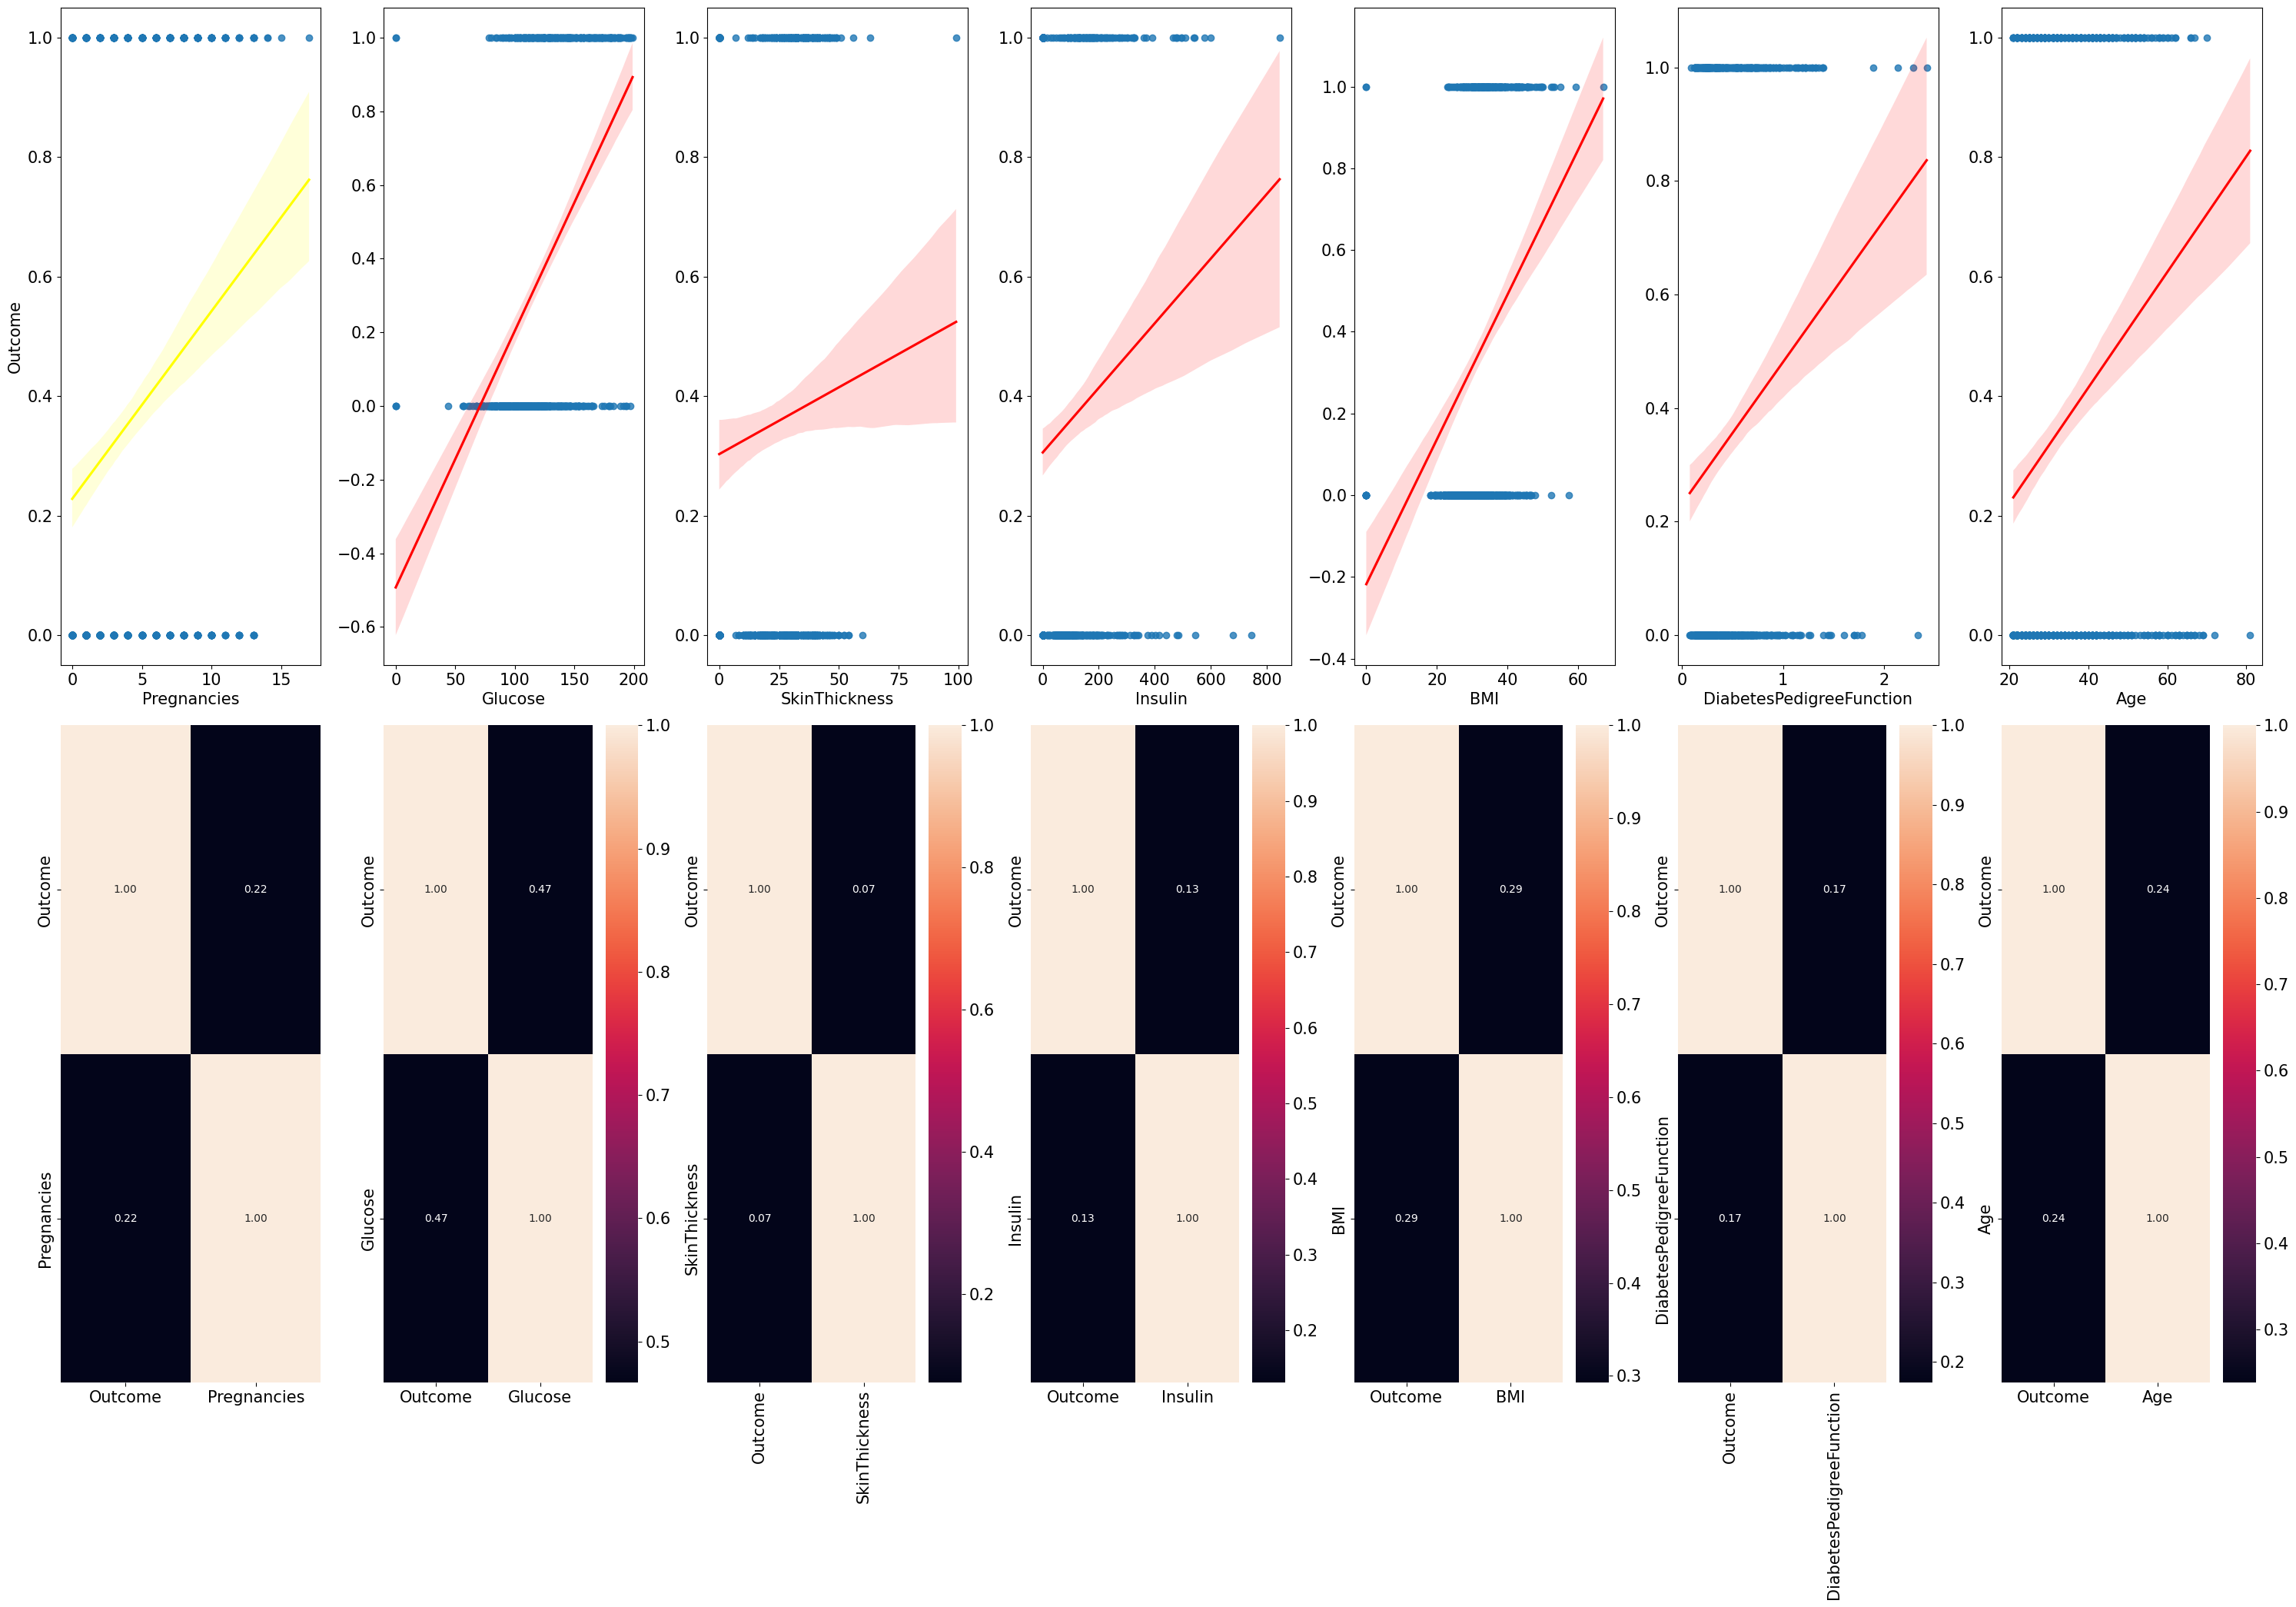

In [72]:
# Generamos las correlaciones

corr_charges_preg = df[['Outcome', 'Pregnancies']].corr()
corr_charges_glu = df[['Outcome', 'Glucose']].corr()
corr_charges_skin = df[['Outcome', 'SkinThickness']].corr()
corr_charges_ins = df[['Outcome', 'Insulin']].corr()
corr_charges_bmi = df[['Outcome', 'BMI']].corr()
corr_charges_diab = df[['Outcome', 'DiabetesPedigreeFunction']].corr()
corr_charges_age = df[['Outcome', 'Age']].corr()


# Crear un diagrama de dispersión múltiple
fig, axis = plt.subplots(2, 7, figsize=(30, 21))

sns.regplot(ax=axis[0, 0], data=df, x="Pregnancies", y='Outcome', line_kws={'color': 'yellow'})
sns.heatmap(ax=axis[1, 0], data=corr_charges_preg, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[0, 1], data=df, x="Glucose", y='Outcome', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 1], data=corr_charges_glu, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 2], data=df, x="SkinThickness", y='Outcome', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 2], data=corr_charges_skin, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 3], data=df, x="Insulin", y='Outcome', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 3], data=corr_charges_ins, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 4], data=df, x="BMI", y='Outcome', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 4], data=corr_charges_bmi, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 5], data=df, x="DiabetesPedigreeFunction", y='Outcome', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 5], data=corr_charges_diab, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 6], data=df, x="Age", y='Outcome', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 6], data=corr_charges_age, annot=True, fmt=".2f")


plt.tight_layout()

> ##### Observaciones:
>
> - `Pregnancies` tiene una relación directa con `age` y `bmi`.
> - `Glucose` no tiene mucha relacion, no afecta demasiado con `Outcome`

##### Análisis de correlaciones

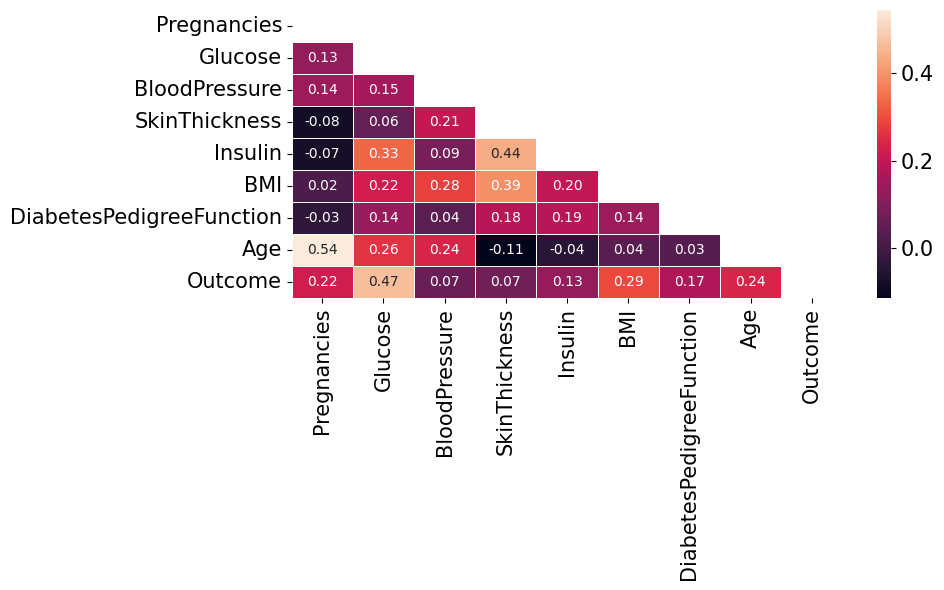

In [73]:
corr = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()

> ##### Observaciones:
>
> La target `Outcome` muestra una fuerte correlación con `Glucose`, `BMI`, `Age`.
> - El análisis de correlaciones refleja una fuerte relación directa entre la `edad` y `pregnancies`.
> - `Insuline` tiene una fuerte relación con `Glucose` y `SkinThickness`.
> - `BMI` el indice de masa corporal esta muy relacionado con el grosor de la piel `SkinThickness`.

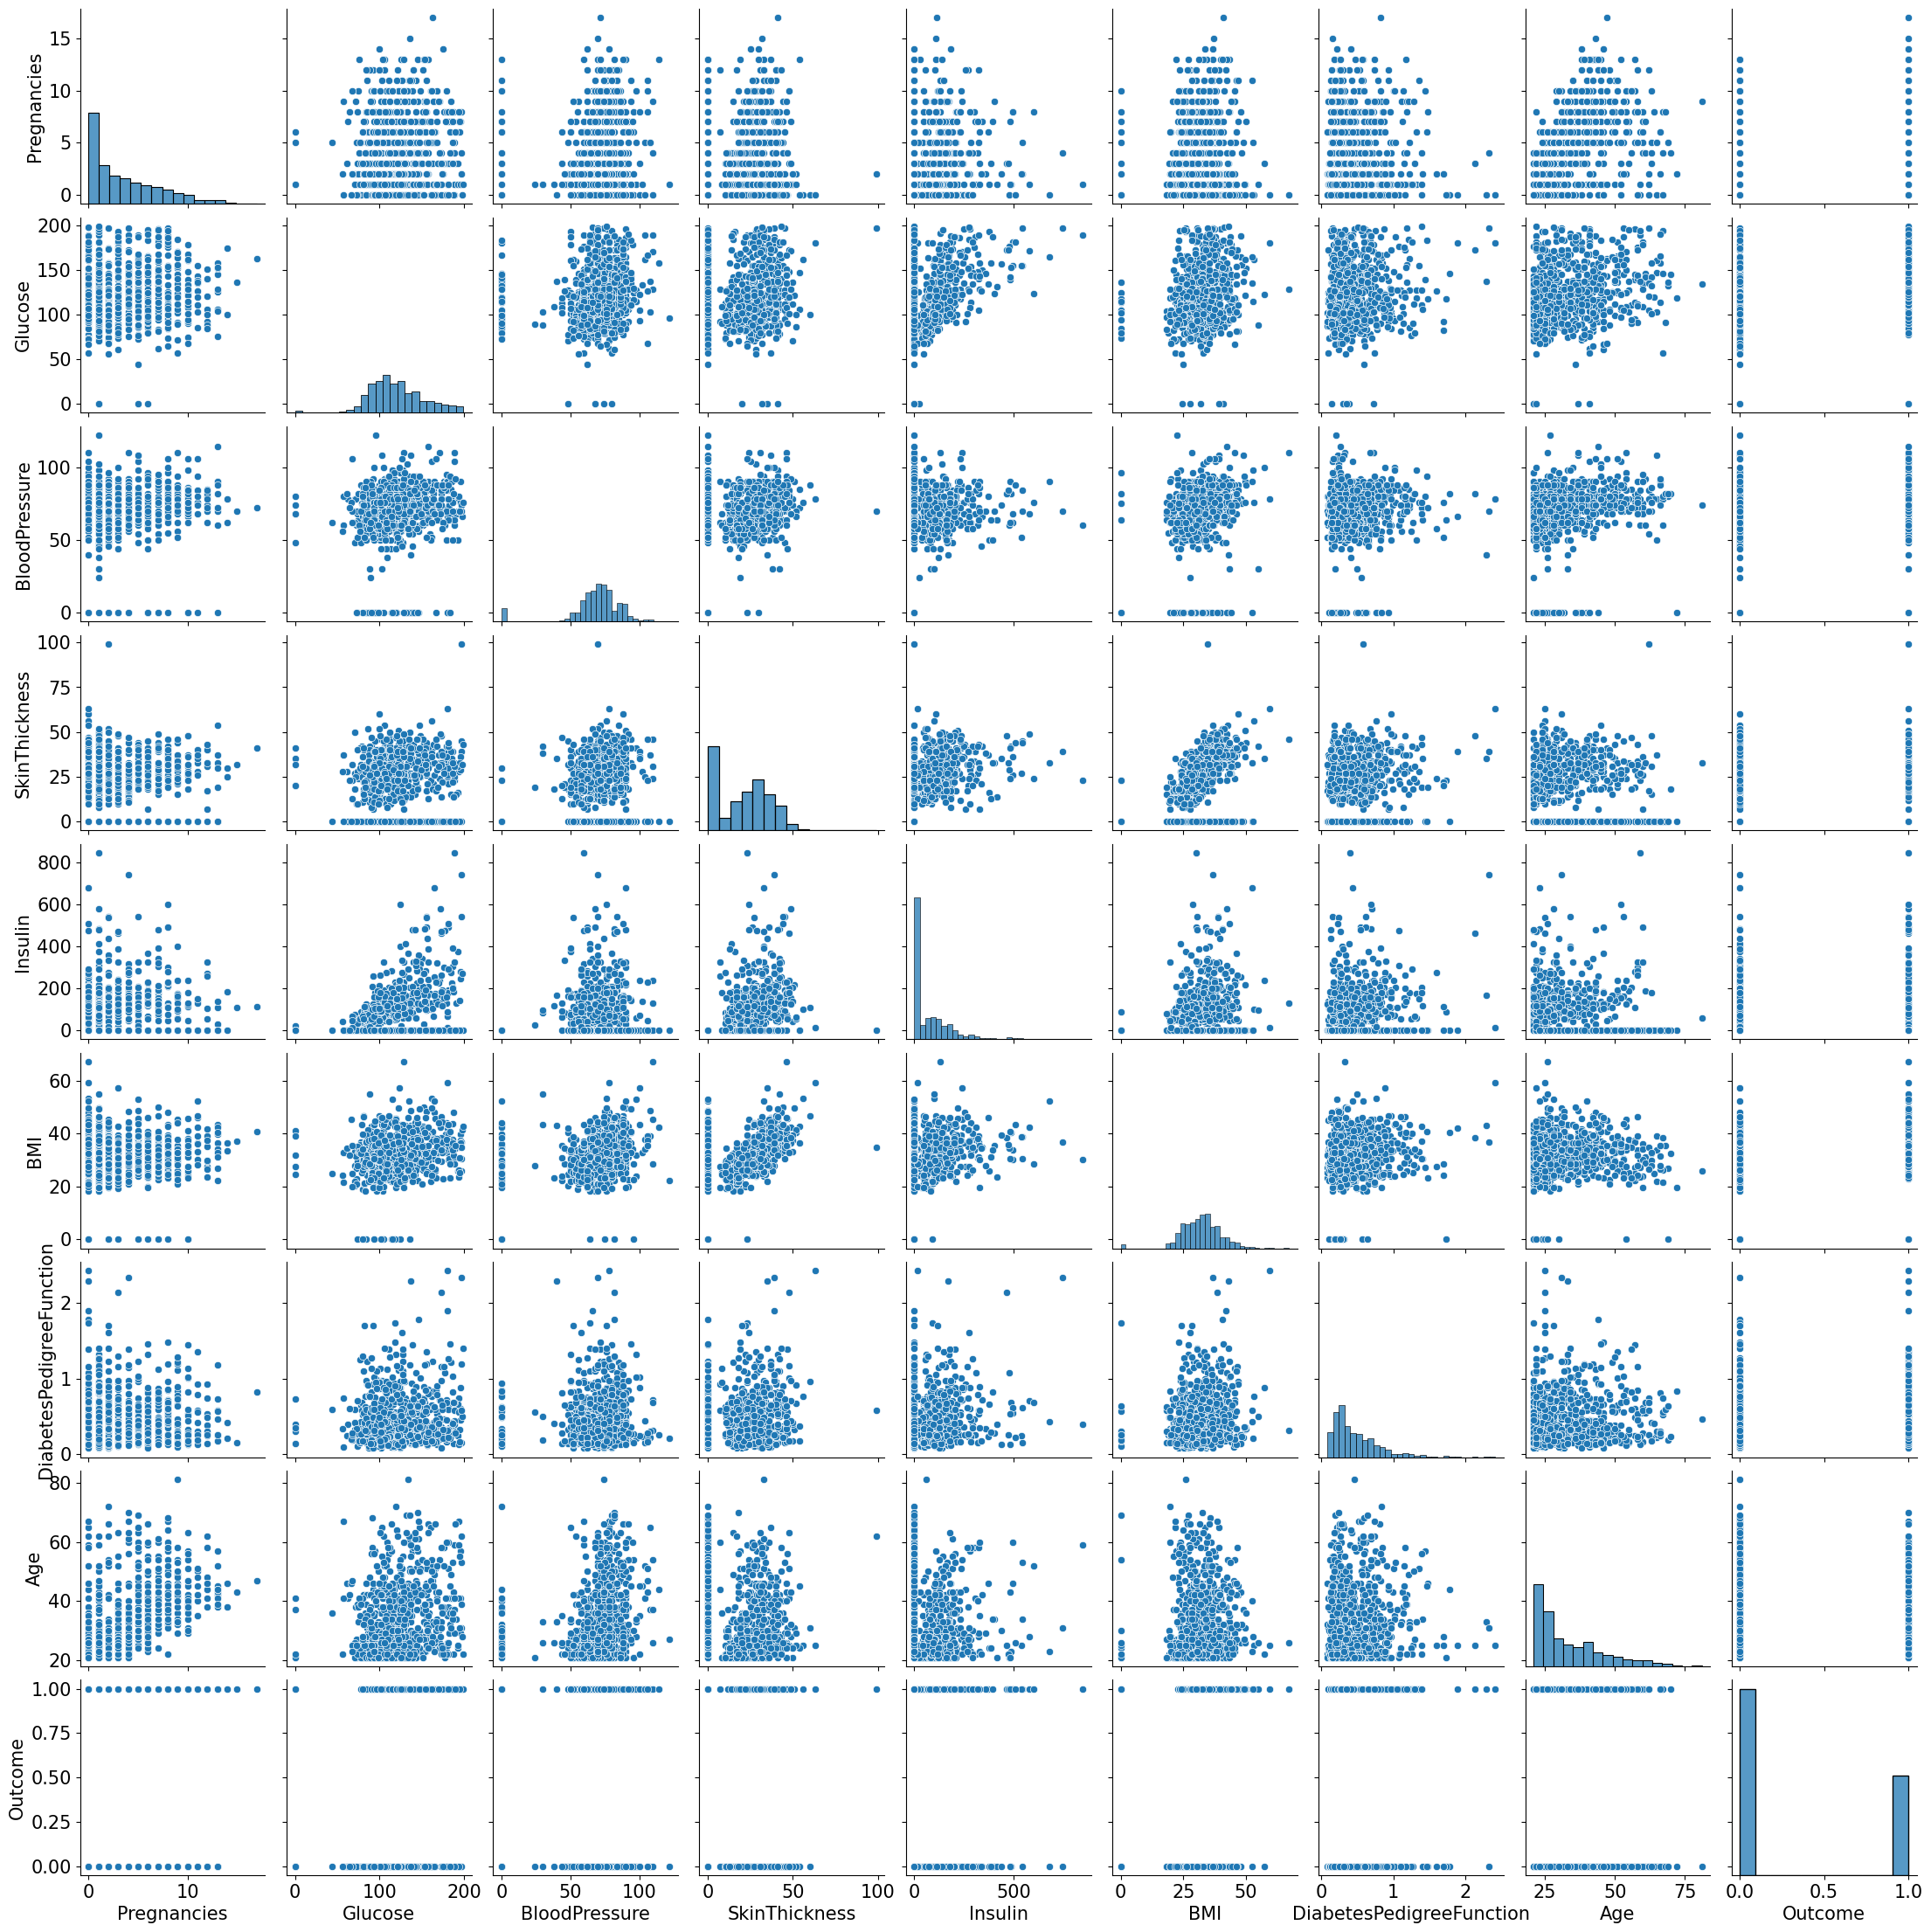

In [74]:
sns.pairplot(data=df)

## Paso 6: Ingeniería de características

#### Análisis de outliers

**Outliers: Análisis descriptivo**

In [75]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### Observaciones:
>
> La columna `bmi` el indice de masa corporal tiene outliers asi como `charges`.

**Outliers: Visualización**

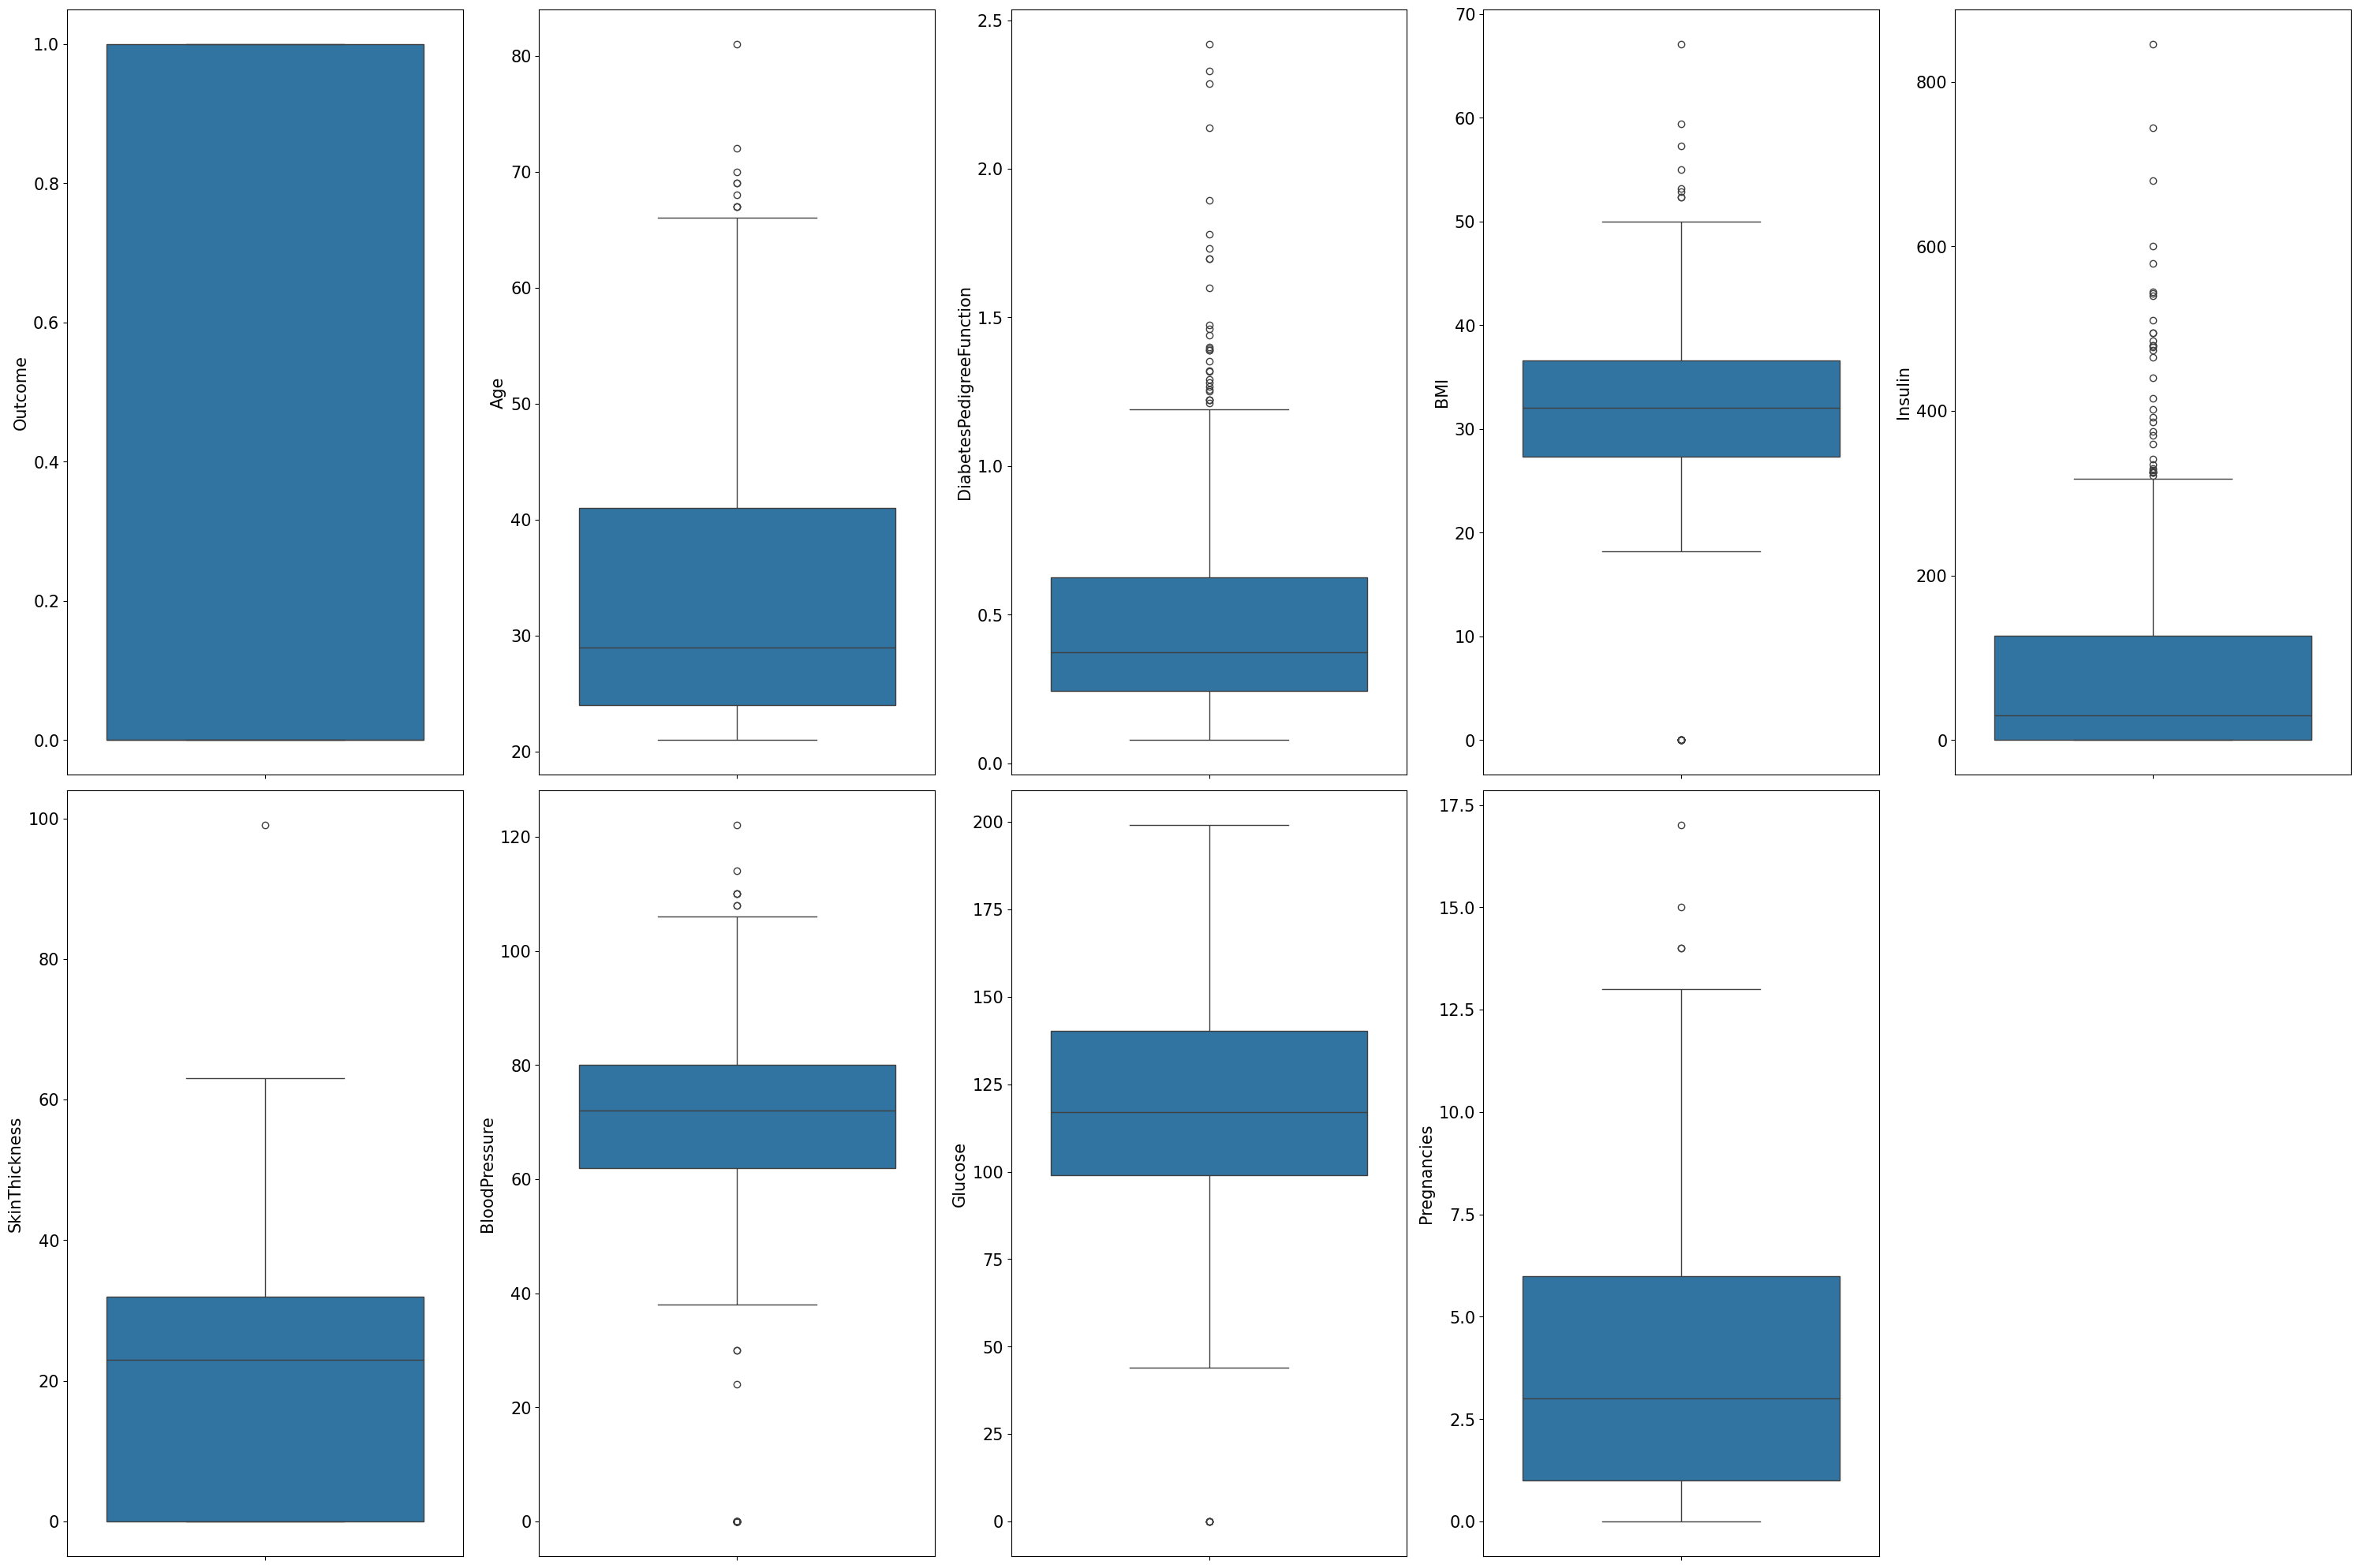

In [76]:
fig, axis = plt.subplots(2, 5, figsize=(30, 20))

sns.boxplot(ax=axis[0, 0], data=df, y='Outcome')
sns.boxplot(ax=axis[0, 1], data=df, y='Age')
sns.boxplot(ax=axis[0, 2], data=df, y='DiabetesPedigreeFunction')
sns.boxplot(ax=axis[0, 3], data=df, y='BMI')
sns.boxplot(ax=axis[0, 4], data=df, y='Insulin')
sns.boxplot(ax=axis[1, 0], data=df, y='SkinThickness')
sns.boxplot(ax=axis[1, 1], data=df, y='BloodPressure')
sns.boxplot(ax=axis[1, 2], data=df, y='Glucose')
sns.boxplot(ax=axis[1, 3], data=df, y='Pregnancies')
fig.delaxes(axis[1, 4])

plt.tight_layout()
plt.show()

#### Observaciones:
>
> - Las variables que principalmente muestran mas outliers son `DiabetesPedigreeFunction`, `BMI`, `Insulin`.

#### Análisis de outliers

In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### Observaciones:
> - Validamos la visualización anterior además en esta tabla observamos como claramente hay valores 0 en columnas donde es inusual que puedan ser reales estos valores.

Se procede a eliminar outliers utilizando el quantile 0.99 en aquellas columnas que corresponda.

In [78]:
#I created a dictionary with the necessary calculated percentiles for every column needed.
quantile_columns = {'Pregnancies':df['Pregnancies'].quantile(0.99),
                  'SkinThickness':df['SkinThickness'].quantile(0.99),
                  'Insulin':df['Insulin'].quantile(0.99),
                  'DiabetesPedigreeFunction':df['DiabetesPedigreeFunction'].quantile(0.99)
                  }

#I combined conditions to accelerate the coding process.
filter_combined_condition = ((df['Pregnancies'] <= quantile_columns['Pregnancies']) &
                            (df['SkinThickness'] <= quantile_columns['SkinThickness']) &
                            (df['Insulin'] <= quantile_columns['Insulin']) &
                            (df['DiabetesPedigreeFunction'] <= quantile_columns['DiabetesPedigreeFunction'])
                            )
#Apply the filter to the DataFrame
df = df[filter_combined_condition]

Conteo de ceros por columna.

In [79]:
(df['Glucose'] == 0).sum(), (df['SkinThickness'] == 0).sum(), (df['BloodPressure'] == 0).sum(), (df['BMI'] == 0).sum(),

(np.int64(5), np.int64(226), np.int64(35), np.int64(10))

Para Tratar los valores 0 en las características correspondientes, paso los valores 0 a NAN para hacer la media sin estos valores y a continuación aplico la media de cada característica a su valor 0.

In [80]:
cols_to_impute = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)

# 2. Calcular la mediana de cada columna **excluyendo los NaNs**
median_values = df[cols_to_impute].median()

# 3. Rellenar los NaNs con la mediana correspondiente
df.fillna(median_values, inplace=True)

/tmp/ipykernel_4556/138810935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)
/tmp/ipykernel_4556/138810935.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(median_values, inplace=True)


In [81]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,742.0,4.386792,2.893520,1.000,2.0000,4.0000,6.000,13.000
Glucose,742.0,120.734501,29.844824,44.000,99.0000,116.0000,139.000,199.000
BloodPressure,742.0,72.439353,12.115546,24.000,64.0000,72.0000,80.000,122.000
SkinThickness,742.0,28.648248,7.991831,7.000,25.0000,29.0000,32.000,51.000
Insulin,742.0,73.609164,99.879730,0.000,0.0000,18.0000,125.000,510.000
BMI,742.0,32.205121,6.726986,18.200,27.4000,32.0000,36.100,67.100
DiabetesPedigreeFunction,742.0,0.453982,0.290611,0.078,0.2415,0.3645,0.605,1.698
Age,742.0,33.168464,11.746647,21.000,24.0000,29.0000,40.000,81.000
Outcome,742.0,0.340970,0.474355,0.000,0.0000,0.0000,1.000,1.000


#### Análisis de valores faltantes

In [82]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

##### Observaciones:
> - No hay valores nulos

## Paso 7: Split

### Realizamos el split

In [83]:
#Dividimos el conjunto de datos en muestras de train y test
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [84]:
X_train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [85]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
76,7.0,62.0,78.0,29.0,0,32.6,0.391,41
257,2.0,114.0,68.0,22.0,0,28.7,0.092,25
194,8.0,85.0,55.0,20.0,0,24.4,0.136,42
237,4.0,179.0,90.0,27.0,0,44.1,0.686,23
651,1.0,117.0,60.0,23.0,106,33.8,0.466,27


In [86]:
y_train

76     0
257    0
194    0
237    1
651    0
      ..
184    0
728    0
129    1
290    0
314    1
Name: Outcome, Length: 593, dtype: int64

## Paso 8: Scaling & Encoding

### Scaling - Escalado de valores

#### Normalización

##### Realizar el escalando con el dataset dividido

Solo con el conjunto de Entrenamiento
Calculas la media ($\mu$) y la desviación estándar ($\sigma$) SOLO con los datos de entrenamiento:

In [87]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [88]:
num_variables = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
              'BMI', 'DiabetesPedigreeFunction', 'Age']
norm_scaler = StandardScaler()
norm_scaler.fit(X_train[num_variables]) # Calcula media y std SOLO en train

,copy,True
,with_mean,True
,with_std,True


In [89]:
#TRANSFORM en X_train y X_test
X_train[num_variables] = norm_scaler.transform(X_train[num_variables])
X_test[num_variables] = norm_scaler.transform(X_test[num_variables])

#### Escalado Mínimo-Máximo

In [90]:
# Lista de variables a escalar (SOLO las numéricas/codificadas)
num_variables_escalar = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
                        'BMI', 'DiabetesPedigreeFunction', 'Age']

minmax_scaler = MinMaxScaler()

minmax_scaler.fit(X_train[num_variables_escalar]) 

X_train[num_variables_escalar] = minmax_scaler.transform(X_train[num_variables_escalar])
X_test[num_variables_escalar] = minmax_scaler.transform(X_test[num_variables_escalar])


Verificar que los datos están ahora en el rango [0, 1] revisando las estadísticas de las columnas.

In [91]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,593.0,0.281478,0.238802,0.0,0.083333,0.250000,0.416667,1.0
Glucose,593.0,0.499157,0.194540,0.0,0.361290,0.464516,0.612903,1.0
BloodPressure,593.0,0.495595,0.124709,0.0,0.408163,0.489796,0.571429,1.0
SkinThickness,593.0,0.490533,0.177923,0.0,0.409091,0.500000,0.568182,1.0
Insulin,593.0,0.148755,0.204323,0.0,0.000000,0.000000,0.254902,1.0
BMI,593.0,0.288088,0.139088,0.0,0.188139,0.282209,0.366053,1.0
DiabetesPedigreeFunction,593.0,0.232289,0.182764,0.0,0.098148,0.171605,0.331481,1.0
Age,593.0,0.204469,0.198593,0.0,0.050000,0.133333,0.333333,1.0


## Paso 9: Selección de características

In [92]:
selection_model = SelectKBest(f_regression)
# Con un valor de k=5 queremos decir implícitamente que queremos eliminar 2 características del conjunto de datos

selection_model.fit(X_train, y_train)

# Aplico el modelo a los datos X_train y X_test
selection_model_transform_train = selection_model.transform(X_train)
selection_model_transform_test = selection_model.transform(X_test)

# Obtener los índices de las columnas seleccionadas
ix = selection_model.get_support()

# Genero los dataframes usando los nombres de columna del DF codificado
X_train_sel = pd.DataFrame(selection_model_transform_train, 
                           columns=X_train.columns[ix])
X_test_sel = pd.DataFrame(selection_model_transform_test, 
                          columns=X_test.columns[ix])

X_train_sel.head()

/home/vscode/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=10 is greater than n_features=8. All the features will be returned.
  warnings.warn(


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.500000,0.116129,0.551020,0.500000,0.000000,0.294479,0.193210,0.333333
1,0.083333,0.451613,0.448980,0.340909,0.000000,0.214724,0.008642,0.066667
2,0.583333,0.264516,0.316327,0.295455,0.000000,0.126789,0.035802,0.350000
3,0.250000,0.870968,0.673469,0.454545,0.000000,0.529652,0.375309,0.033333
4,0.000000,0.470968,0.367347,0.363636,0.207843,0.319018,0.239506,0.100000


In [93]:
# Guardamos utilizando Pickle (que nos permite guardar objetos de Python)
with open('../data/processed/diabetes.pkl', 'wb') as file:
    pickle.dump(df, file)